notes: mention the AAH failed predictions, WRITE A SCRIPT

# A little bit about CNNs...

## Why CNN?

CNNs are known to work GREAT for images because
- Local receptive fields (we'll look at this later)
- Parameter sharing: the same filter (weights) is applied to the whole image, a model does not need 784 weights per neuron for $28 \times 28$ images (looking at you, Fully Connected Networks..)
    - We only need 9 weights! Since we're using a $3 \times 3$ filter 
- Efficiently encode spatial structure and learn hierarchical features

## How?

$$S(i, j) = (I * K)(i, j) = \sum_m\sum_n I(i + m, j + n) \cdot K(m, n)$$

Where
- $I$ is the input image
- $K$ is the _kernel_
- $S$ is the output feature map
- $i$ and $j$ are the spatial coordinates of the feature map

<div style="text-align: center;">
    <img src="kernel.gif" alt="segment" title="segment" style="width:15%; display: block; margin-left: auto; margin-right: auto;">
</div>

### In my CNN, I have 16 of these in the first convolutional layer, each learning different features (edges, curves, etc.)

## Architecture 

### Part 1: Convolutional Layers

- **Input shape:** `(N, 1, 28, 28)`
    - N = Batch size
    - 1 = Grayscale channel
    - 28, 28 = Image size 

- **First layer: 1st convolution block**
    - Applies 16 $3 \times 3$ filters to the input (kernel) with a padding of $1$ so that it does not exceed the images' edges
    - Output shape: `(N, 16, 28, 28)`
    - Params: $(1 \times 3 \times 3 + 1) \times 16 = 160$

- **ReLU**
    - Introduces non-linearity
    - $\text{ReLU}(x) = \max(0, x)$
    - Output shape remains unchanged

- **MaxPool2d**
    - Take the maximum value in each $2\times 2$ window and reduces spatial dimensions by half
    - Output shape: `(N, 16, 14, 14)`

- **Second layer: ANOTHER convolution block**
    - Applies 32 different $3\times 3$ filters to each of the 16 input channels
    - Output shape: `(N, 32, 14, 14)`
    - Params: $(16 \times 3\times 3 + 1) \times 32 = 4,640$

- **ReLU + MaxPool2d**
    - Output shape: `(N, 32, 7, 7)`

### Part 2: Fully Connected Layers

- **Flatten**
    - flattens $32\times 7 \times 7 = 1,568$ features into a 1D vector
    - Output shape: `(N, 1568)`

- **Linear layer**
    - Reduces 1568 features to 64
    - Output shape: `(N, 64)`
    - Params: $(1,568 \times 64) + 64 = 100,416$

- **ANOTHER ReLU**
    - you know what this does 

- **Dropout**
    - Randomly zero 25% of neurons during training to prevent overfitting
    - Output shape: `(N, 64)` (unchanged)

- **Linear layer**
    - Final classification layer 
    - Output shape: `(N, 10)` - logits for each class, pick the class with the highest probability
    - Params: $(64 \times 10) + 10 = 650$

### Total number of parameters: $160 + 4,640 + 100,416 + 650 = 105,866$

## Training: Gradient descent and epochs

### The goal 

Minimize the loss function $\mathcal{L}$ by adjusting weights $w$:

$$w_{\text{new}} = w_{\text{old}} - \eta \nabla_w\mathcal{L}$$

Where: 
- $\eta$: learning rate (we use 0.001 as our initial learning rate, however we'll let GridSearchCV determine our best choice)
    - Our optimizer, Adam, adjusts this $\eta$ for each param during training
- $\nabla_w\mathcal{L}$: gradient of the loss w.r.t. $w$, i.e., $\frac{\partial \mathcal{L}}{\partial w}$

<div style="text-align: center;">
    <img src="image.png" alt="segment" title="segment" style="width:50%; display: block; margin-left: auto; margin-right: auto;">
</div>

### A high / static $\eta$ can lead to an overshoot of local/global minima

### Epochs: how many times to see the data?

An epoch is one complete pass through the entire training dataset

During each epoch: 
- The model sees all training examples at once
- Weights are updated after each batch 
- The model gradually improves its predictions

#### The tradeoff: 

- **Too few epochs:** $\to$ Underfitting
    - Model doesn't generalize 
    - High training loss
- **Too many epochs:** $\to$ Overfitting
    - Model memorizes training data rather than generalizing
    - Low training loss but really poor testing performance 

# How do we evaluate a model?

Poor practice to use *just* accuracy – if your test set is $n = 102$ and there are $101$ 1s and your model guesses 1 every time, then accuracy $\sim 100\%$

- We want both good precision and recall
    - **Precision:** Of all instances prediced as positive, what percentage were *actually* positive?
    - **Recall:** Of all *actual* positive instances, what percentage did the model correctly identify?


### F1 score combines both precision and recall into one tangible number

$$
F1 = \frac{2\times \text{Precision}\times \text{Recall}}{\text{Precision} + \text{Recall}}
$$



#### Honorable mention: Mikhail Belkin: "if we just keep training the model, it will overcome overfitting" (paraphrase)

Belkin demonstrated in a [paper](https://arxiv.org/abs/1812.11118) that both model complexity and training epochs can exhibit "double descent". Performance initially worsens after interpolating the trainings data, then surprisingly improves again with further increases.

This applies (but is not limited) to: 
- CNNs
- ResNets
- transformers

**Why???**
- We actually do not know (yet) :D
- OpenAI: "We leave fully understanding the mechanisms behind double descent in deep neural networks as an important open question."

<div style="text-align: center;">
    <img src="image2.png" alt="segment" title="segment" style="width:50%; display: block; margin-left: auto; margin-right: auto;">
</div>

(source: OpenAI)



# Imports and data loading

In [7]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from cnn_classifier import CNNClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import torch
import warnings

warnings.filterwarnings('ignore')

mnist = fetch_openml('mnist_784', version=1, parser='auto')

seed = 42
k = 5
models = {}

# Wrangle the data

(split into X and y, normalize – this happens in the pipeline, split into train / test, visualize)

We normalize because gradient descent converges faster when features are on a similar scale

In [8]:
X, y = mnist.data.values, mnist.target.astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed #use 70% of data for training
)

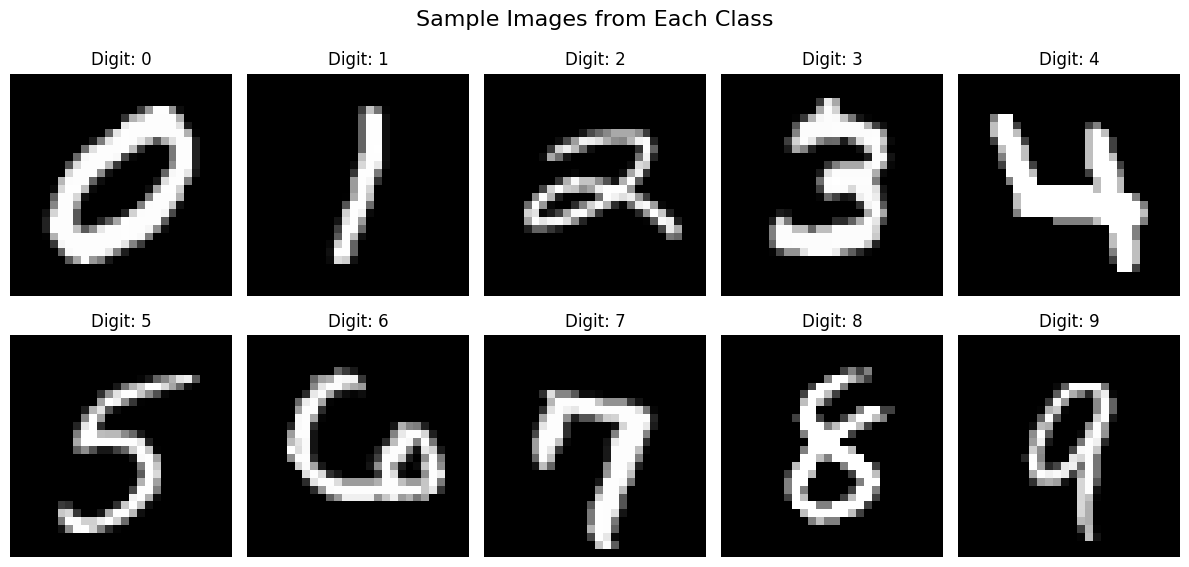

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample Images from Each Class', fontsize=16)

for digit in range(10):
    # Find the first occurrence of each digit in the training set
    idx = np.where(y_train == digit)[0][0]
    
    # Reshape the flattened image back to 28x28
    image = X_train[idx].reshape(28, 28)
    
    # Plot in the appropriate subplot
    row = digit // 5
    col = digit % 5
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Digit: {digit}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


# Class distribution

We need to keep the class distribution in mind. If it is heavily skewed, we should use balancing methods (SMOTE) to mitigate that.

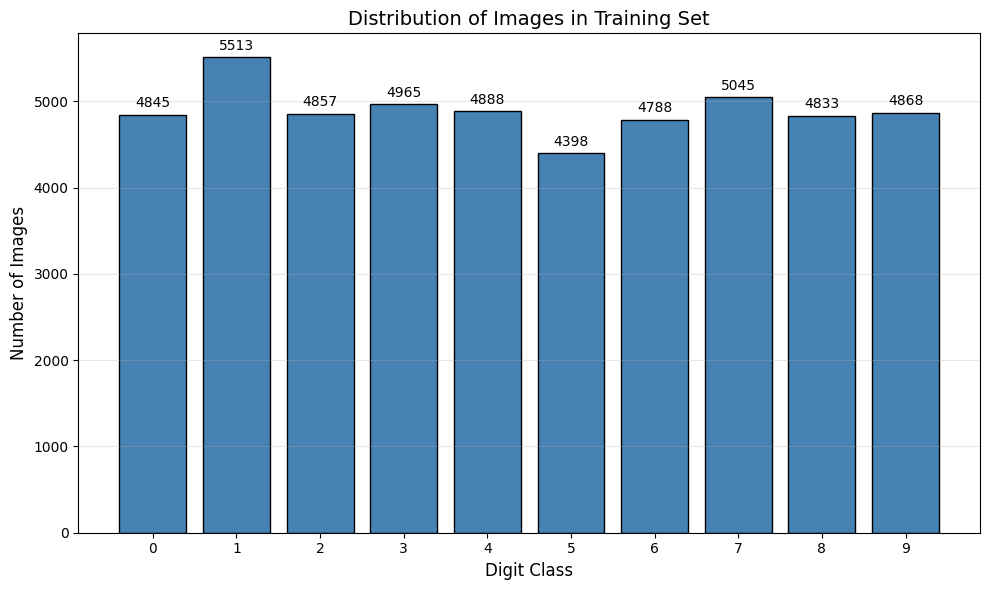

In [10]:
# Class Distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xlabel('Digit Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images in Training Set', fontsize=14)
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)

# Add count labels on top of each bar
for i, (digit, count) in enumerate(zip(unique, counts)):
    plt.text(digit, count + 50, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
kf = KFold(n_splits=k, shuffle=True, random_state=seed)

model = Pipeline([('scaler', StandardScaler()), ('cnn', CNNClassifier())])

params = {
    # 'cnn__learning_rate' : [0.001],
    'cnn__learning_rate' : [0.001, 0.0005, 0.00025],
    # 'cnn__num_epochs' : [10]
    'cnn__num_epochs' : [30, 40, 50, 60, 70]
}

clf = GridSearchCV(model, params, cv=kf, verbose=1, n_jobs=1, scoring='f1_weighted')


temp_cnn = CNNClassifier()
device_info = f'Training on device: {temp_cnn.device}'
if torch.cuda.is_available():
    device_info += f' ({torch.cuda.get_device_name(0)})'
print(device_info)
del temp_cnn

clf.fit(X_train, y_train)

models[clf.best_estimator_] = clf.best_score_

print(f'Best Parameters from GridSearchCV:')
for param, value in clf.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest Cross-Validation F1 Score: {clf.best_score_:.4f}')

Training on device: cuda (NVIDIA GeForce RTX 5090)
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters from GridSearchCV:
  cnn__learing_rate: 0.00025
  cnn__num_epochs: 60

Best Cross-Validation F1 Score: 0.9891


# Testing on the Test Set

Test Set Performance:
Accuracy: 0.9896
F1 Score (weighted): 0.9896

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2058
           1       0.99      1.00      0.99      2364
           2       0.99      0.99      0.99      2133
           3       1.00      0.99      0.99      2176
           4       0.99      0.99      0.99      1936
           5       0.98      0.99      0.99      1915
           6       0.99      0.99      0.99      2088
           7       0.98      0.99      0.99      2248
           8       0.99      0.98      0.99      1992
           9       0.98      0.99      0.99      2090

    accuracy                           0.99     21000
   macro avg       0.99      0.99      0.99     21000
weighted avg       0.99      0.99      0.99     21000



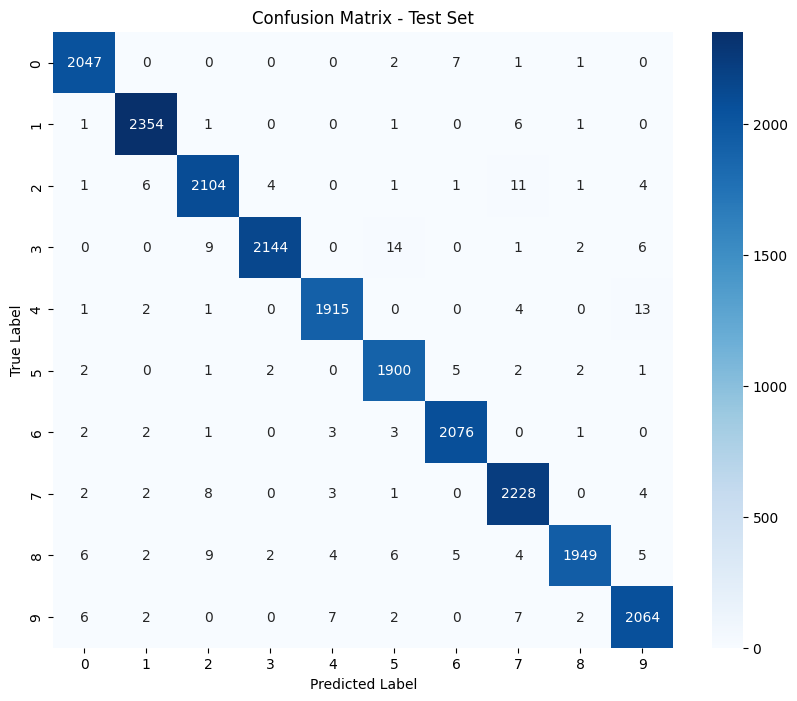


Number of misclassified samples: 219 out of 21000


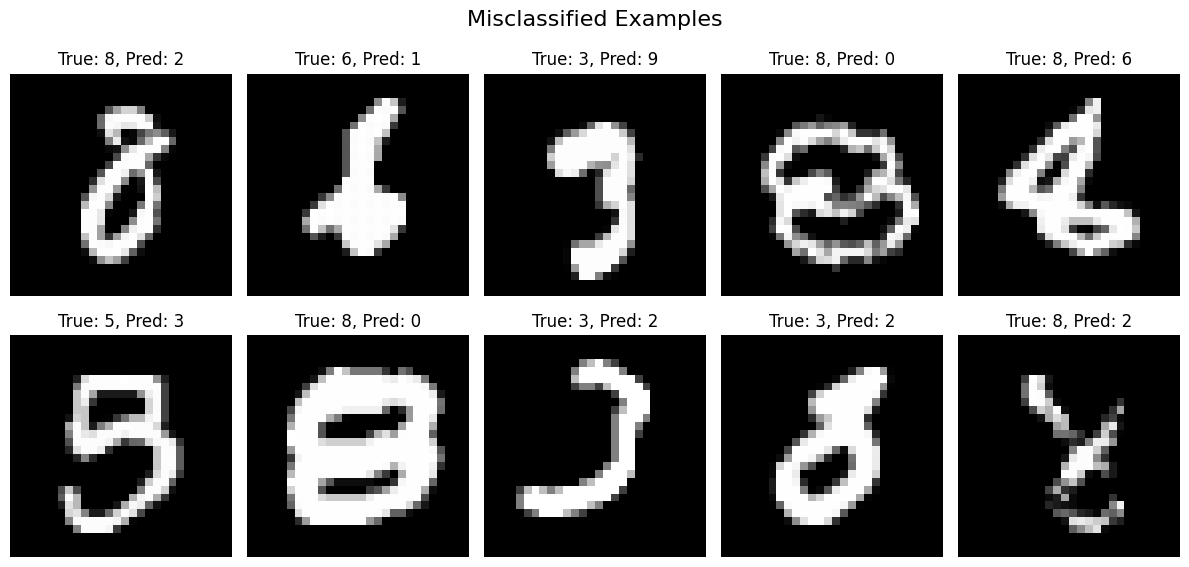

In [12]:
# Get the best model from GridSearchCV
best_model = clf.best_estimator_

# Make predictions on test set
y_pred = best_model.predict(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Test Set Performance:')
print(f'Accuracy: {test_accuracy:.4f}')
print(f'F1 Score (weighted): {test_f1:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Show some misclassified examples
misclassified_idx = np.where(y_pred != y_test)[0]
if len(misclassified_idx) > 0:
    print(f'\nNumber of misclassified samples: {len(misclassified_idx)} out of {len(y_test)}')
    
    # Plot some misclassified examples
    n_examples = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Misclassified Examples', fontsize=16)
    
    for i in range(n_examples):
        idx = misclassified_idx[i]
        image = X_test[idx].reshape(28, 28)
        
        row = i // 5
        col = i % 5
        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'True: {y_test[idx]}, Pred: {y_pred[idx]}')
        axes[row, col].axis('off')
    
    # Hide any unused subplots
    for i in range(n_examples, 10):
        row = i // 5
        col = i % 5
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print('\nNo misclassified samples!')
